<a href="https://colab.research.google.com/github/Kalana-Lakshan/ML-Self-Learning/blob/main/Scaling_and_Encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
data = {
    'Age':[20,33,45,56,88,99,110],
    'Salary':[30000,44000,51000,66000,78000,90000,105000],
    'Response':['Happy','Neutral','Neutral','Sad','Happy','Happy','Neutral'],
    'Gender':['Male','Male','Female','Female','Male','Male','Male']
}


In [37]:
df = pd.DataFrame(data)
df

,Age,Salary,Response,Gender
0,20,30000,Happy,Male
1,33,44000,Neutral,Male
2,45,51000,Neutral,Female
3,56,66000,Sad,Female
4,88,78000,Happy,Male
5,99,90000,Happy,Male
6,110,105000,Neutral,Male


<Axes: xlabel='Response', ylabel='Gender'>

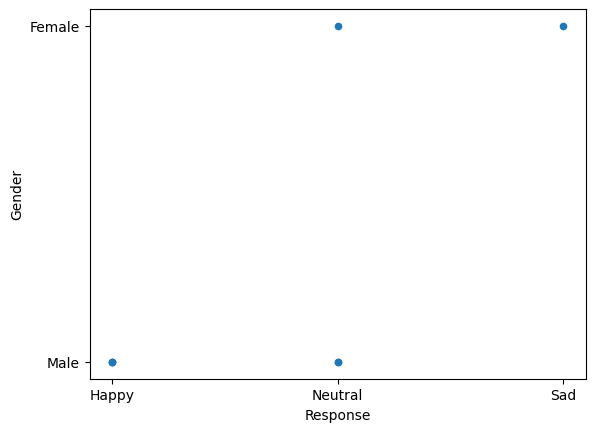

In [38]:
df.plot(kind='scatter',x = 'Response',y = 'Gender')

In [39]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
scaled_mms = min_max_scaler.fit_transform(df[['Age','Salary']])


In [40]:
df_mms = pd.DataFrame(scaled_mms,columns = ['Age','Salary'])
df_mms

,Age,Salary
0,0.000000,0.000000
1,0.144444,0.186667
2,0.277778,0.280000
3,0.400000,0.480000
4,0.755556,0.640000
5,0.877778,0.800000
6,1.000000,1.000000


In [41]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
scaled_ss = std_scaler.fit_transform(df[['Age','Salary']])
df_ss = pd.DataFrame(scaled_ss,columns = ['Age','Salary'])
df_ss

,Age,Salary
0,-1.381690,-1.473411
1,-0.977401,-0.904930
2,-0.604212,-0.620689
3,-0.262121,-0.011602
4,0.733051,0.475668
5,1.075142,0.962938
6,1.417232,1.572025


In [42]:
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(categories = [['Sad','Neutral','Happy']])
encoded_oe = ord_enc.fit_transform(df[['Response']])
df_oe = pd.DataFrame(encoded_oe,columns=['Response'])
df_oe



,Response
0,2.0
1,1.0
2,1.0
3,0.0
4,2.0
5,2.0
6,1.0


In [43]:
from sklearn.preprocessing import OneHotEncoder

one_hot_enc = OneHotEncoder(sparse_output=False)
encoded_ohe = one_hot_enc.fit_transform(df[['Gender']])
feature_names = one_hot_enc.get_feature_names_out(['Gender'])
df_ohe = pd.DataFrame(encoded_ohe,columns = feature_names)
df_ohe

,Gender_Female,Gender_Male
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,0.0,1.0
5,0.0,1.0
6,0.0,1.0


In [44]:
df_final = pd.concat([df_mms,df_ss,df_oe,df_ohe],axis = 1)
df_final

,Age,Salary,Age,Salary,Response,Gender_Female,Gender_Male
0,0.000000,0.000000,-1.381690,-1.473411,2.0,0.0,1.0
1,0.144444,0.186667,-0.977401,-0.904930,1.0,0.0,1.0
2,0.277778,0.280000,-0.604212,-0.620689,1.0,1.0,0.0
3,0.400000,0.480000,-0.262121,-0.011602,0.0,1.0,0.0
4,0.755556,0.640000,0.733051,0.475668,2.0,0.0,1.0
5,0.877778,0.800000,1.075142,0.962938,2.0,0.0,1.0
6,1.000000,1.000000,1.417232,1.572025,1.0,0.0,1.0
